/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Validation AUC: 0.7261


/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_34360/2846402145.py:64: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_shap, max_display=30, show=True)


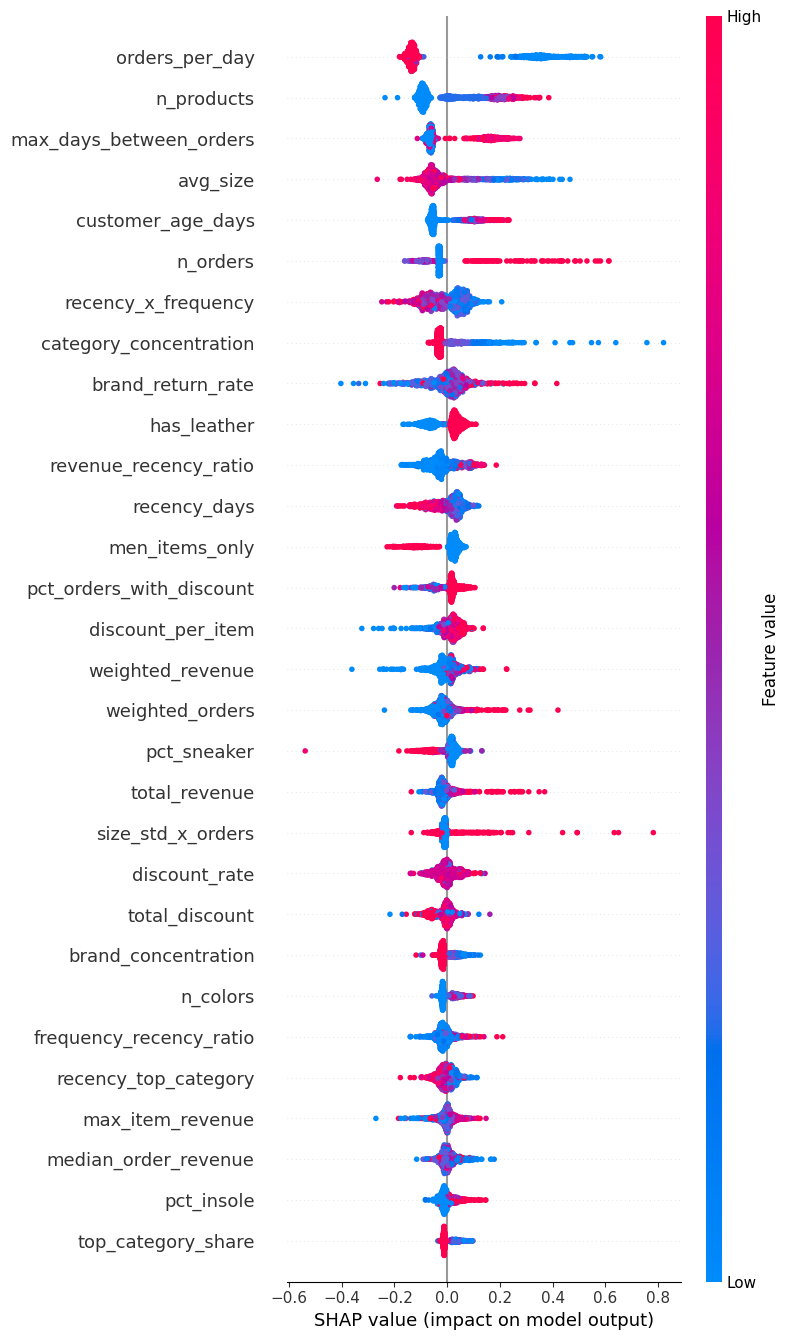

/tmp/ipykernel_34360/2846402145.py:67: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_shap, plot_type="bar", max_display=30, show=True)


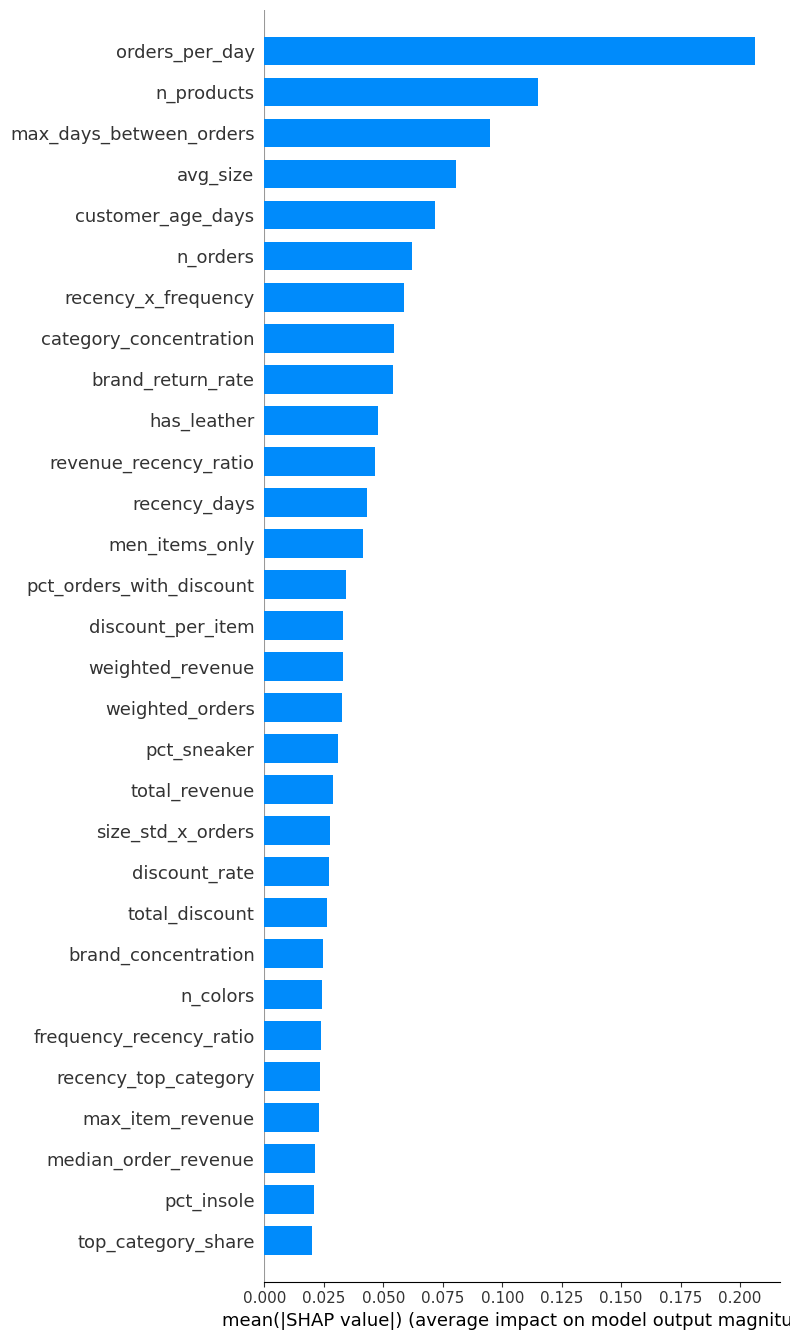


Volledige SHAP feature ranking:
orders_per_day                0.206480
n_products                    0.115257
max_days_between_orders       0.094916
avg_size                      0.080628
customer_age_days             0.071892
n_orders                      0.061974
recency_x_frequency           0.058563
category_concentration        0.054667
brand_return_rate             0.054183
has_leather                   0.047740
revenue_recency_ratio         0.046420
recency_days                  0.043078
men_items_only                0.041570
pct_orders_with_discount      0.034296
discount_per_item             0.033235
weighted_revenue              0.033043
weighted_orders               0.032761
pct_sneaker                   0.030790
total_revenue                 0.028906
size_std_x_orders             0.027647
discount_rate                 0.027238
total_discount                0.026458
brand_concentration           0.024664
n_colors                      0.024287
frequency_recency_ratio       0

In [1]:
import pandas as pd
import numpy as np
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# ── Data laden ────────────────────────────────────────────────────────────────
features = pd.read_csv("../data/customer_features_lowie1.csv")
train    = pd.read_csv("../data/customer_clv_train.csv")
df = train.merge(features, on="cust_id", how="left")

# Churn target
df["returned"] = (df["revenue_2018_2019"] > 0).astype(int)

# Feature kolommen
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols
                if c not in ("cust_id", "revenue_2018_2019", "returned")]
df[feature_cols] = df[feature_cols].fillna(0)

# ── Split ─────────────────────────────────────────────────────────────────────
X = df[feature_cols]
y = df["returned"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Snel LightGBM churn model ─────────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
model.fit(X_train, y_train)

# Validatie
p_val = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, p_val)
print(f"Validation AUC: {auc:.4f}")

# ── SHAP ──────────────────────────────────────────────────────────────────────
explainer = shap.TreeExplainer(model)

np.random.seed(42)
shap_idx = np.random.choice(len(X_val), size=min(1000, len(X_val)), replace=False)
X_shap   = X_val.iloc[shap_idx].reset_index(drop=True)

shap_vals = explainer.shap_values(X_shap)

# ── Plot 1: Beeswarm — top 30 features ───────────────────────────────────────
shap.summary_plot(shap_vals, X_shap, max_display=30, show=True)

# ── Plot 2: Bar chart — mean |SHAP| ──────────────────────────────────────────
shap.summary_plot(shap_vals, X_shap, plot_type="bar", max_display=30, show=True)

# ── Tabel: volledige ranking ──────────────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print("\nVolledige SHAP feature ranking:")
print(mean_abs_shap.to_string())

# ── Consistentie-check ────────────────────────────────────────────────────────
print(f"\n--- Consistentie-check ---")
print(f"Gemiddelde churn kans (val):    {p_val.mean():.4f}")
print(f"Werkelijke fractie returners:   {y_val.mean():.4f}")